In [1]:
# Optimized Fibonacci Retracement Strategy
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import ta
from scipy import stats

# Step 1: Download Data and Add Technical Indicators
def prepare_data(ticker, start_date, end_date):
    df = yf.download(ticker, start=start_date, end=end_date)
    df.columns = df.columns.get_level_values(-2)
    
    # Add RSI
    df['RSI'] = ta.momentum.RSIIndicator(df['Close']).rsi()
    
    # Add MACD
    macd = ta.trend.MACD(df['Close'])
    df['MACD'] = macd.macd()
    df['MACD_Signal'] = macd.macd_signal()
    
    # Add ATR for volatility-based position sizing
    df['ATR'] = ta.volatility.AverageTrueRange(df['High'], df['Low'], df['Close']).average_true_range()
    
    # Add Volume indicators
    df['OBV'] = ta.volume.OnBalanceVolumeIndicator(df['Close'], df['Volume']).on_balance_volume()
    
    return df.dropna()

# Step 2: Enhanced Fibonacci Levels Calculation
def calculate_fibonacci_levels(df, period=60):
    recent_high = df['High'].rolling(window=period).max()
    recent_low = df['Low'].rolling(window=period).min()
    
    fib_ratios = {
        'Fibo_0.0': 0.0,
        'Fibo_23.6': 0.236,
        'Fibo_38.2': 0.382,
        'Fibo_50.0': 0.5,
        'Fibo_61.8': 0.618,
        'Fibo_78.6': 0.786,
        'Fibo_100': 1.0
    }
    
    fib_levels = pd.DataFrame()
    for name, ratio in fib_ratios.items():
        fib_levels[name] = recent_high - (recent_high - recent_low) * ratio
    
    return fib_levels

# Step 3: Improved Signal Generation with Multiple Confirmations
def generate_signals(df, risk_per_trade=0.02):
    df['Signal'] = 0
    df['Position_Size'] = 0
    
    for i in range(1, len(df)):
        close = df['Close'].iloc[i]
        fibo_618 = df['Fibo_61.8'].iloc[i]
        fibo_382 = df['Fibo_38.2'].iloc[i]
        rsi = df['RSI'].iloc[i]
        macd = df['MACD'].iloc[i]
        macd_signal = df['MACD_Signal'].iloc[i]
        
        # Buy conditions with multiple confirmations
        buy_conditions = (
            close < fibo_618 and  # Price below 61.8% level
            rsi < 40 and          # RSI showing oversold
            macd > macd_signal    # MACD bullish crossover
        )
        
        # Sell conditions with multiple confirmations
        sell_conditions = (
            close > fibo_382 and  # Price above 38.2% level
            rsi > 70 and          # RSI showing overbought
            macd < macd_signal    # MACD bearish crossover
        )
        
        # Position sizing based on ATR
        position_size = risk_per_trade / (df['ATR'].iloc[i] / close)
        
        if buy_conditions:
            df.iloc[i, df.columns.get_loc('Signal')] = 1
            df.iloc[i, df.columns.get_loc('Position_Size')] = position_size
        elif sell_conditions:
            df.iloc[i, df.columns.get_loc('Signal')] = -1
            df.iloc[i, df.columns.get_loc('Position_Size')] = position_size
            
    return df

# Step 4: Enhanced Backtest with Risk Management
def backtest_strategy(df, initial_capital=10000, stop_loss_pct=0.02, take_profit_pct=0.03):
    capital = initial_capital
    position = 0
    entry_price = 0
    portfolio = []
    trades = []
    
    for i in range(len(df)):
        close = df['Close'].iloc[i]
        signal = df['Signal'].iloc[i]
        position_size = df['Position_Size'].iloc[i]
        
        # Check stop loss and take profit if in position
        if position != 0:
            pnl_pct = (close - entry_price) / entry_price
            if (position > 0 and pnl_pct <= -stop_loss_pct) or (position > 0 and pnl_pct >= take_profit_pct):
                capital = position * close
                trades.append({
                    'exit_date': df.index[i],
                    'exit_price': close,
                    'pnl': capital - initial_capital
                })
                position = 0
                
        # Execute new trades
        if signal == 1 and position == 0:
            position = (capital * position_size) / close
            entry_price = close
            capital = 0
            trades.append({
                'entry_date': df.index[i],
                'entry_price': close
            })
        elif signal == -1 and position > 0:
            capital = position * close
            position = 0
            trades.append({
                'exit_date': df.index[i],
                'exit_price': close,
                'pnl': capital - initial_capital
            })
            
        portfolio_value = capital + position * close
        portfolio.append(portfolio_value)
        
    df['Portfolio'] = portfolio
    return df, trades

# Step 5: Enhanced Performance Metrics
def calculate_performance_metrics(df, trades):
    daily_returns = df['Portfolio'].pct_change().dropna()
    
    metrics = {
        'Sharpe_Ratio': np.mean(daily_returns) / np.std(daily_returns) * np.sqrt(252),
        'Max_Drawdown': (df['Portfolio'] / df['Portfolio'].cummax() - 1).min(),
        'Total_Return': (df['Portfolio'].iloc[-1] / df['Portfolio'].iloc[0] - 1),
        'Win_Rate': len([t for t in trades if t.get('pnl', 0) > 0]) / len(trades) if trades else 0,
        'Profit_Factor': sum(t['pnl'] for t in trades if t.get('pnl', 0) > 0) / abs(sum(t['pnl'] for t in trades if t.get('pnl', 0) < 0)) if trades else 0
    }
    
    return metrics

# Step 6: Enhanced Visualization
def plot_strategy(df, ticker):
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), gridspec_kw={'height_ratios': [2, 1, 1]})
    
    # Price and Portfolio Plot
    ax1.plot(df['Close'], label='Price', alpha=0.7)
    ax1.plot(df['Portfolio'], label='Portfolio', linestyle='--')
    ax1.scatter(df[df['Signal'] == 1].index, df[df['Signal'] == 1]['Close'], 
                marker='^', color='g', label='Buy', alpha=1)
    ax1.scatter(df[df['Signal'] == -1].index, df[df['Signal'] == -1]['Close'], 
                marker='v', color='r', label='Sell', alpha=1)
    
    # Plot Fibonacci levels
    for col in df.columns:
        if col.startswith('Fibo_'):
            ax1.plot(df[col], '--', alpha=0.3, label=col)
    
    ax1.set_title(f'{ticker} - Fibonacci Strategy Performance')
    ax1.legend()
    
    # RSI Plot
    ax2.plot(df['RSI'], label='RSI')
    ax2.axhline(y=70, color='r', linestyle='--', alpha=0.5)
    ax2.axhline(y=30, color='g', linestyle='--', alpha=0.5)
    ax2.set_title('RSI Indicator')
    ax2.legend()
    
    # MACD Plot
    ax3.plot(df['MACD'], label='MACD')
    ax3.plot(df['MACD_Signal'], label='Signal')
    ax3.bar(df.index, df['MACD'] - df['MACD_Signal'], alpha=0.3, label='MACD Histogram')
    ax3.set_title('MACD Indicator')
    ax3.legend()
    
    plt.tight_layout()
    plt.show()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
C:\Users\rponn\AppData\Local\Temp\ipykernel_8112\124393737.py:86: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.48890840868964963' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[i, df.columns.get_loc('Position_Size')] = position_size



Strategy Performance Metrics:
Sharpe_Ratio: -1.89
Max_Drawdown: -100.00%
Total_Return: -100.00%
Win_Rate: 0.00%
Profit_Factor: 0.00


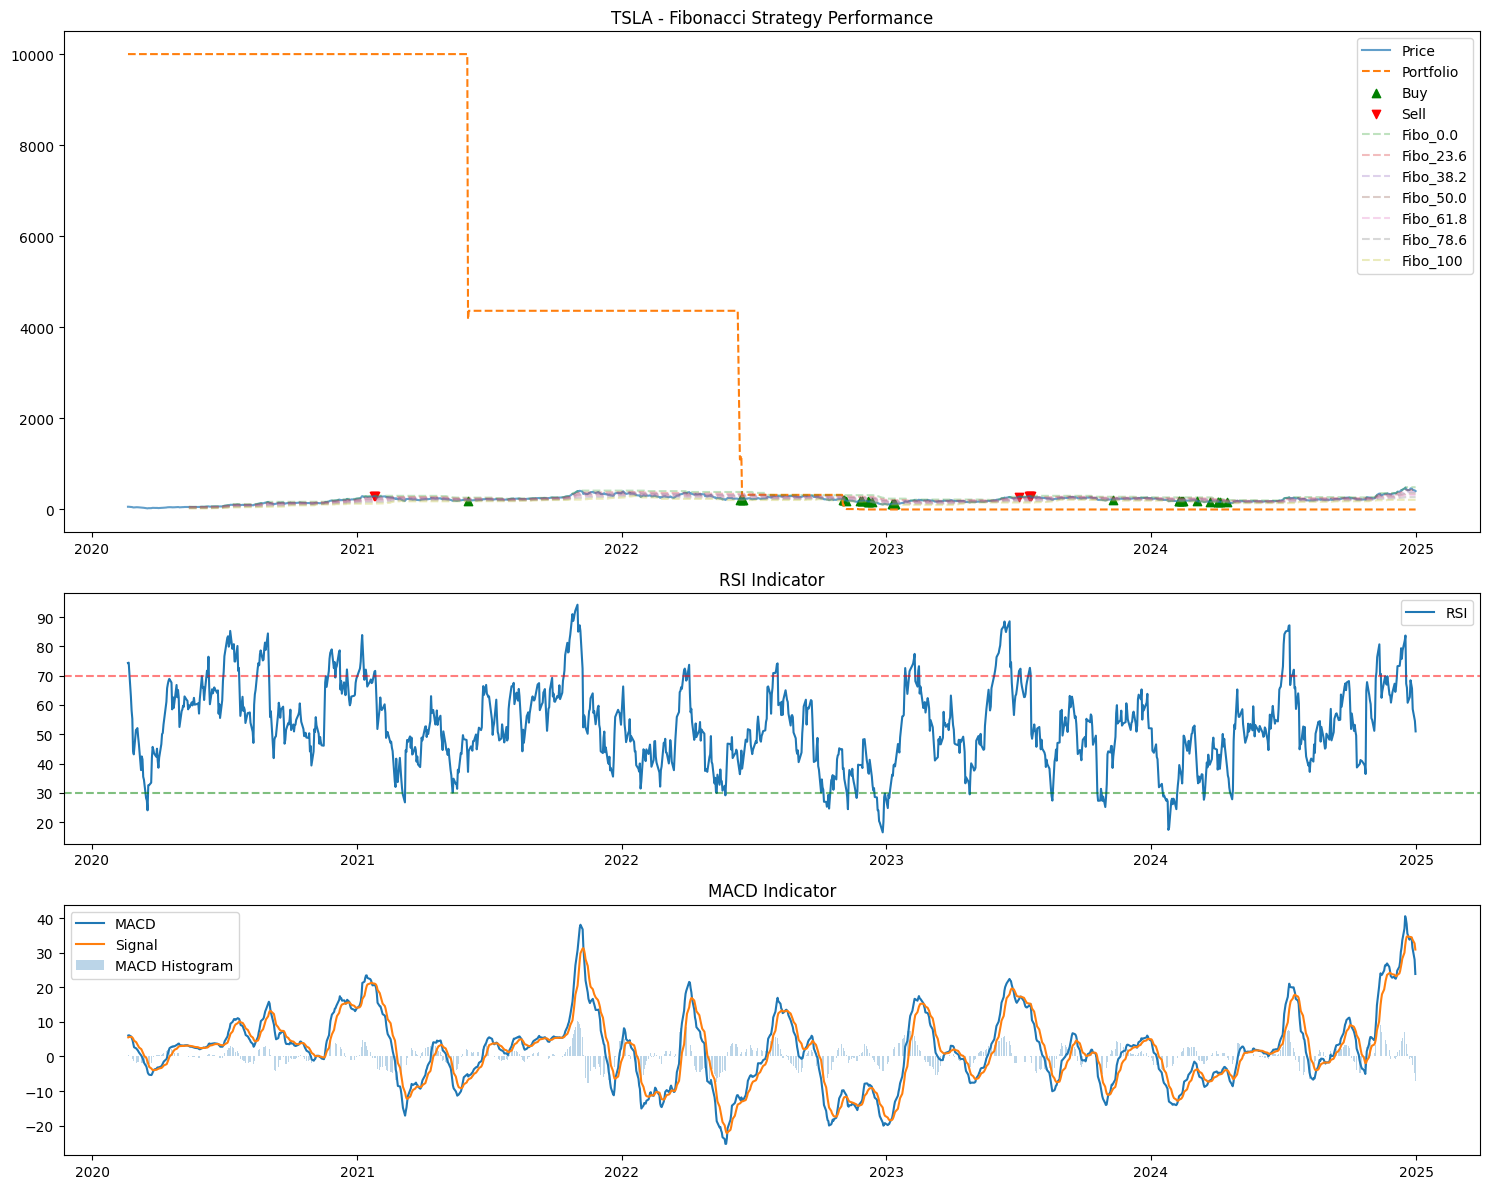

In [2]:
# Run the optimized strategy
ticker = 'TSLA'
df = prepare_data(ticker, '2020-01-01', '2025-01-01')
df = df.join(calculate_fibonacci_levels(df))
df = generate_signals(df)
df, trades = backtest_strategy(df)
metrics = calculate_performance_metrics(df, trades)

# Display results
print("\nStrategy Performance Metrics:")
for metric, value in metrics.items():
    if metric in ['Sharpe_Ratio', 'Profit_Factor']:
        print(f"{metric}: {value:.2f}")
    elif metric in ['Max_Drawdown', 'Total_Return', 'Win_Rate']:
        print(f"{metric}: {value:.2%}")

# Plot the strategy
plot_strategy(df, ticker)